## Praktikum

### D1. Operasi Citra Sederhana

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
---------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-2718713724.py:19: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c]= np.clip(original[y,x,c] + brightness, 0, 255)


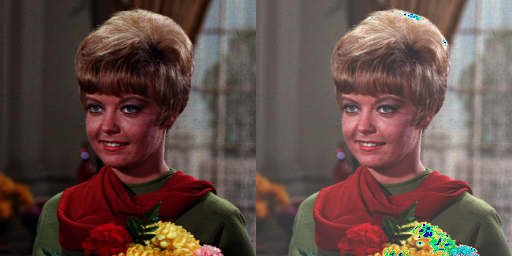

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np

print(' Mengubah tingkat kecerahan citra ')
print('---------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c]= np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## Tugas Praktikum

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:  

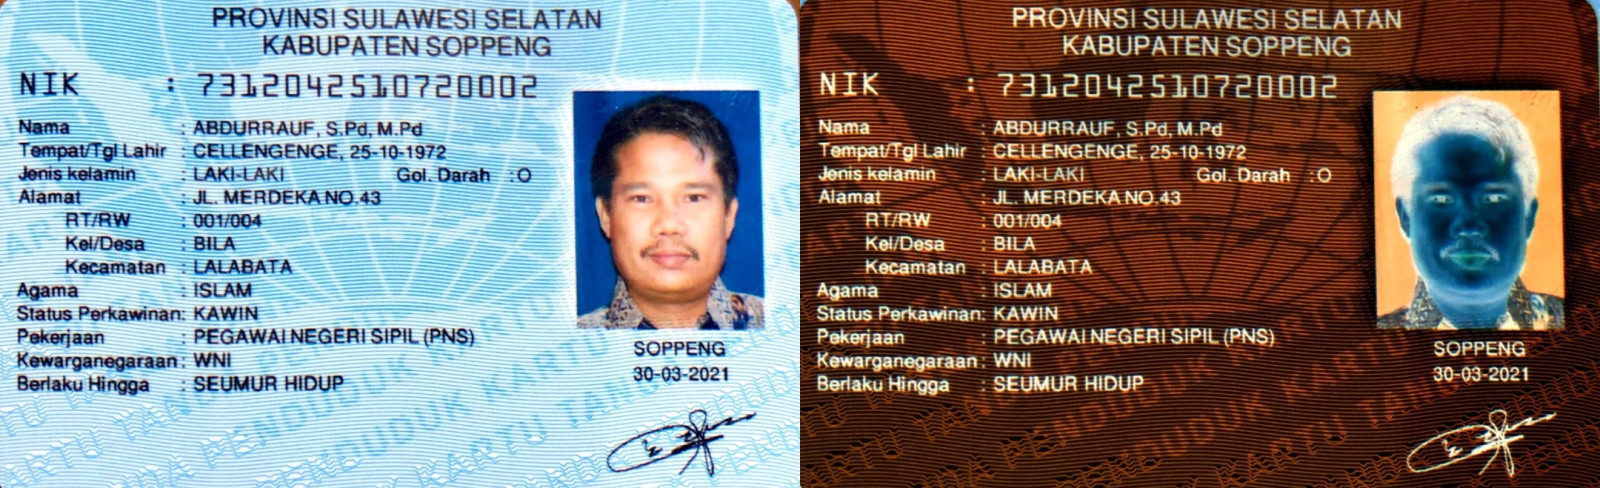

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
inverse_image = cv.bitwise_not(original)
final_frame = cv.hconcat([original, inverse_image])
cv2_imshow(final_frame)

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga menghasilkan keluaran seperti berikut:

 Ubah tingkat kontras dan kecerahan citra 
------------------------------------------
Masukkan nilai kecerahan [-255 - 255]: 50
Masukkan nilai kontras [1.0 - 3.0]: 2


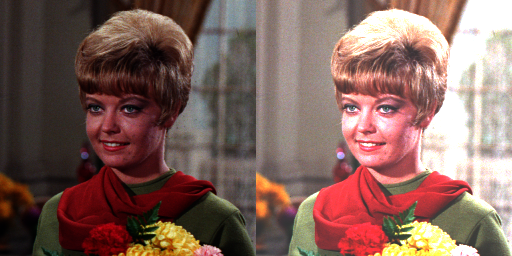

In [ ]:
print(' Ubah tingkat kontras dan kecerahan citra ')
print('------------------------------------------')

# input brightness
try:
  brightness = int(input('Masukkan nilai kecerahan [-255 - 255]: '))
  if brightness < -255 or brightness > 255:
    print("Nilai kecerahan di luar batas, gunakan default = 0")
    brightness = 0
except ValueError:
  print('Error, not a number. Default = 0')
  brightness = 0

# input contrast
try:
  contrast = float(input('Masukkan nilai kontras [1.0 - 3.0]: '))
  if contrast < 1.0 or contrast > 3.0:
    print("Nilai kontras di luar batas, gunakan default = 1.0")
    contrast = 1.0
except ValueError:
  print('Error, not a number. Default = 1.0')
  contrast = 1.0

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
adjusted_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      adjusted_image[y, x, c] = np.clip(
          contrast * original[y, x, c] + brightness, 0, 255
      )

final_frame = cv.hconcat((original, adjusted_image))
cv2_imshow(final_frame)

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi log, sehingga menghasilkan keluaran seperti berikut:

 Transformasi Logarithmic Brightness dengan input kecerahan 
-----------------------------------------------------------
Masukkan nilai kecerahan [-255 - 255]: 50


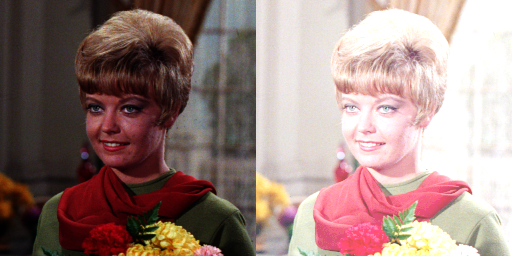

In [ ]:
print(' Transformasi Logarithmic Brightness dengan input kecerahan ')
print('-----------------------------------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan [-255 - 255]: '))
  if brightness < -255 or brightness > 255:
    print("Nilai kecerahan di luar batas, gunakan default = 0")
    brightness = 0
except ValueError:
  print('Error, not a number. Default = 0')
  brightness = 0

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')

original_float = original.astype(float)

c = 255 / np.log(1 + np.max(original_float))

log_image = c * np.log(1 + original_float) + brightness

log_image = np.clip(log_image, 0, 255)

log_image = np.array(log_image, dtype=np.uint8)

final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)

4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness, dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

 Transformasi Grayscale dengan 3 Metode 
-----------------------------------------


(np.float64(-0.5), np.float64(799.5), np.float64(487.5), np.float64(-0.5))

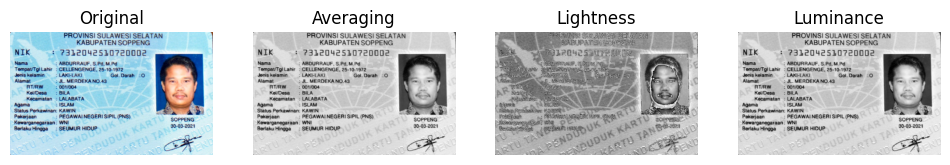

In [ ]:
print(' Transformasi Grayscale dengan 3 Metode ')
print('-----------------------------------------')

import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

original = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
img = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Averaging
gray_avg = np.mean(img, axis=2).astype(np.uint8)

# Lightness
gray_light = ((np.max(img, axis=2) + np.min(img, axis=2)) / 2).astype(np.uint8)

# Luminance
gray_lum = (0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]).astype(np.uint8)

gray_avg_3ch   = cv.merge([gray_avg, gray_avg, gray_avg])
gray_light_3ch = cv.merge([gray_light, gray_light, gray_light])
gray_lum_3ch   = cv.merge([gray_lum, gray_lum, gray_lum])

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gray_avg, cmap='gray')
plt.title("Averaging")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gray_light, cmap='gray')
plt.title("Lightness")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(gray_lum, cmap='gray')
plt.title("Luminance")
plt.axis("off")

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal, tampilkan warna biru pada citra masukan dan ubah bagian lain yang tidak berwarna biru menjadi grayscale seperti pada contoh berikut:

 Isolasi warna biru dan ubah lainnya jadi grayscale 
----------------------------------------------------


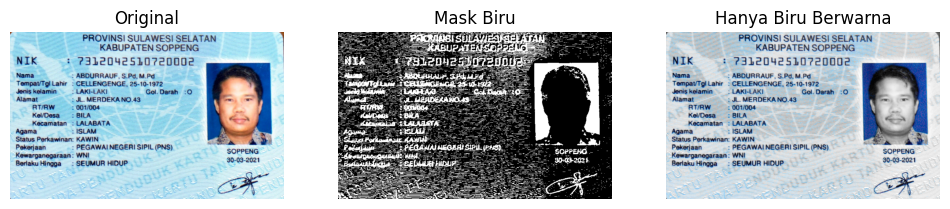

In [ ]:
print(' Isolasi warna biru dan ubah lainnya jadi grayscale ')
print('----------------------------------------------------')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])

mask = cv.inRange(hsv, lower_blue, upper_blue)

colored = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_rgb = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

final = np.where(colored>0, img_rgb, gray_rgb)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask Biru")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(final)
plt.title("Hanya Biru Berwarna")
plt.axis("off")

plt.show()

### D2. Operasi Aritmatika dan Logika

1. Buat Gamma Correction sesuai dengan petunjuk berikut

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


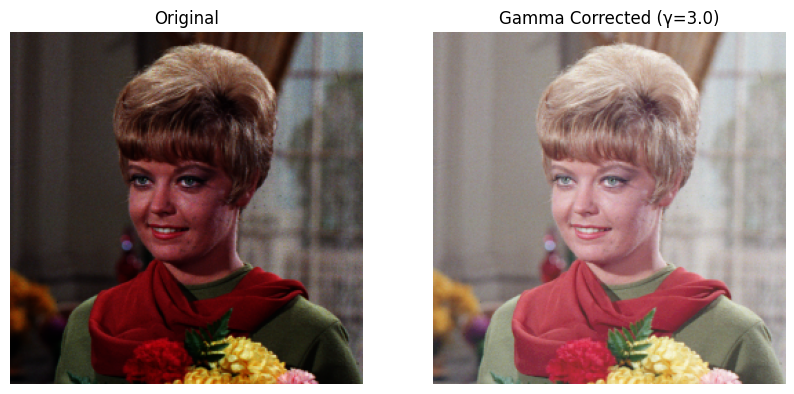

In [ ]:
print(' Gamma Correction pada citra ')
print('----------------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
    if gamma <= 0:
        print("Nilai gamma tidak valid, gunakan default = 1")
        gamma = 1.0
except ValueError:
    print('Error, not a number. Default = 1.0')
    gamma = 1.0

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

normalized = img_rgb / 255.0

gamma_corrected = np.power(normalized, 1.0/gamma)

gamma_corrected = np.uint8(gamma_corrected * 255)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gamma_corrected)
plt.title(f"Gamma Corrected (γ={gamma})")
plt.axis("off")

plt.show()

2. Simulasi Image Depth

 Simulasi Image Depth (Quantization) 
-------------------------------------
Masukkan nilai bit depth [1-8]: 2


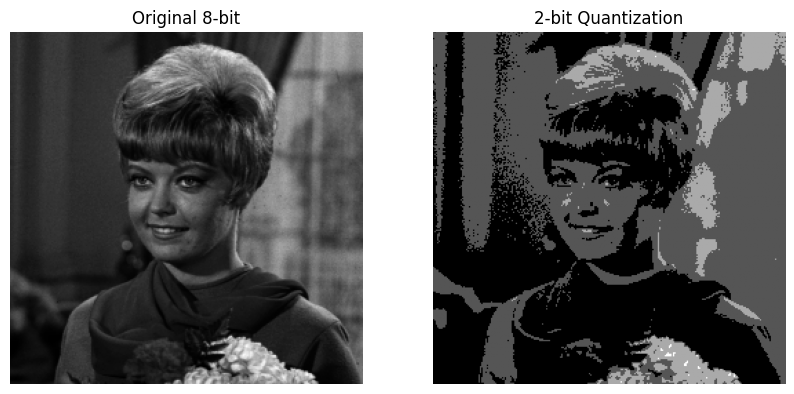

In [ ]:
print(' Simulasi Image Depth (Quantization) ')
print('-------------------------------------')

try:
    bit_depth = int(input('Masukkan nilai bit depth [1-8]: '))
    if bit_depth < 1 or bit_depth > 8:
        print("Nilai bit depth di luar batas, gunakan default = 8")
        bit_depth = 8
except ValueError:
    print('Error, not a number. Default = 8')
    bit_depth = 8

level = 255 / (pow(2, bit_depth) - 1)

# Corrected file path
original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff',
                     cv.IMREAD_GRAYSCALE)

quantized = np.round(original / level) * level
quantized = np.uint8(quantized)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original 8-bit")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(quantized, cmap='gray')
plt.title(f"{bit_depth}-bit Quantization")
plt.axis("off")

plt.show()

3. Modul Average Denoising

### Load Data

In [ ]:
import glob
import cv2 as cv

# Load citra asli
original = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Load citra dengan noise
cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg'):
    n = cv.imread(img)
    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)
    cv_img.append(n)

cv_img = np.array(cv_img)


In [ ]:
def average_denoising(images, jumlah):
    # Ambil 'jumlah' citra pertama dan lakukan perataan
    avg_img = np.mean(images[:jumlah], axis=0).astype(np.uint8)
    return avg_img

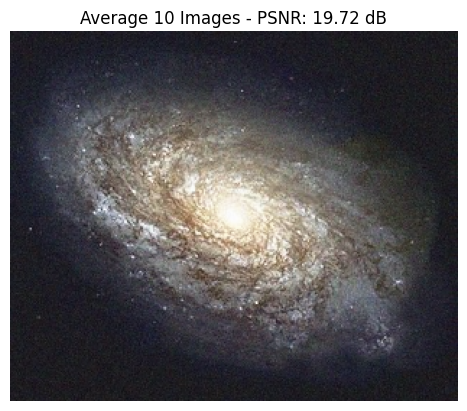

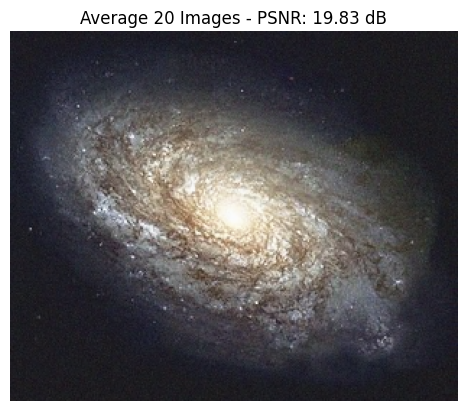

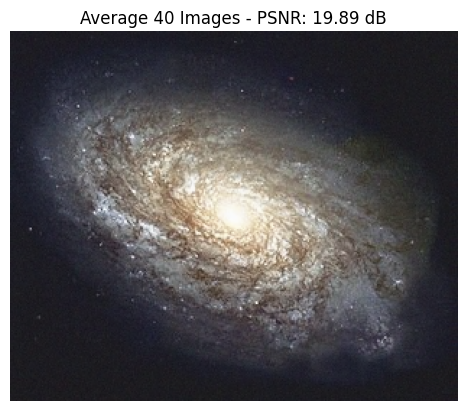

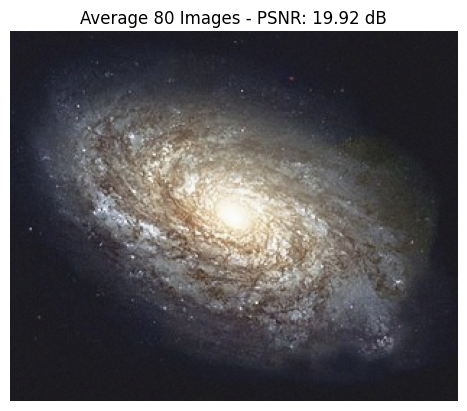

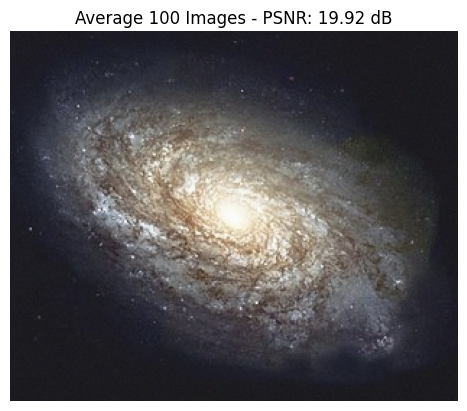

PSNR Values: [np.float64(19.723344705525335), np.float64(19.8299647840586), np.float64(19.888571767429802), np.float64(19.916400248822356), np.float64(19.92196095594035)]


In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr

jumlah_list = [10, 20, 40, 80, 100]
psnr_values = []

for jumlah in jumlah_list:
    denoised = average_denoising(cv_img, jumlah)
    nilai_psnr = psnr(original, denoised)
    psnr_values.append(nilai_psnr)

    # tampilkan hasil salah satu
    plt.figure()
    plt.title(f"Average {jumlah} Images - PSNR: {nilai_psnr:.2f} dB")
    plt.imshow(denoised)
    plt.axis("off")
    plt.show()

print("PSNR Values:", psnr_values)


### Kesimpulan
Semakin banyak citra yang di-average, semakin berkurang noise pada citra hasil. Nilai PSNR meningkat seiring jumlah citra yang digunakan dalam proses average. Metode ini efektif mengurangi noise Gaussian, tetapi butuh banyak citra untuk hasil yang sangat bersih

4. Buat image masking

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
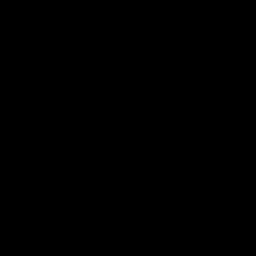

In [ ]:
# Load citra asli
img = cv.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask berbentuk lingkaran
mask1 = np.zeros(img.shape[:2], dtype="uint8")
mask2 = np.zeros(img.shape[:2], dtype="uint8")

cv.circle(mask1, (150, 150), 80, 255, -1)   # lingkaran kiri
cv.circle(mask2, (350, 150), 80, 255, -1)   # lingkaran kanan

In [ ]:
# NOT
not_mask = cv.bitwise_not(mask1)

# OR
or_mask = cv.bitwise_or(mask1, mask2)

# AND
and_mask = cv.bitwise_and(mask1, mask2)

# NAND = NOT(AND)
nand_mask = cv.bitwise_not(and_mask)

# XOR
xor_mask = cv.bitwise_xor(mask1, mask2)


In [ ]:
img_not  = cv.bitwise_and(img, img, mask=not_mask)
img_or   = cv.bitwise_and(img, img, mask=or_mask)
img_and  = cv.bitwise_and(img, img, mask=and_mask)
img_nand = cv.bitwise_and(img, img, mask=nand_mask)
img_xor  = cv.bitwise_and(img, img, mask=xor_mask)

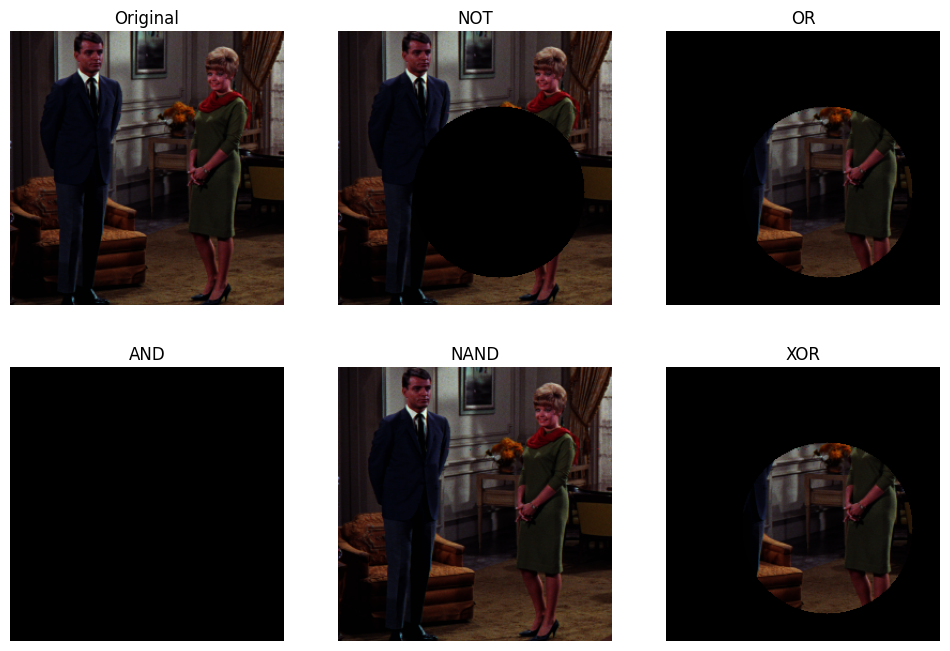

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(231); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(232); plt.imshow(img_not); plt.title("NOT"); plt.axis("off")
plt.subplot(233); plt.imshow(img_or); plt.title("OR"); plt.axis("off")
plt.subplot(234); plt.imshow(img_and); plt.title("AND"); plt.axis("off")
plt.subplot(235); plt.imshow(img_nand); plt.title("NAND"); plt.axis("off")
plt.subplot(236); plt.imshow(img_xor); plt.title("XOR"); plt.axis("off")

plt.show()

### Analisis Hasil
1. NOT (Komplemen)
Semua area yang hitam jadi putih → bagian luar lingkaran yang tadinya hitam berubah jadi area yang terpilih. Jadi hasilnya kebalikan.
2. OR (Atau)
Semua area yang tertutup salah satu lingkaran atau keduanya akan ditampilkan. Jadi citra hasil menampilkan gabungan dua lingkaran.
3. AND (Dan)
Hanya area yang merupakan irisan kedua lingkaran yang ditampilkan. Jadi hasilnya berupa potongan kecil di tengah (daerah overlap).
4. NAND (Not AND)
Kebalikan dari AND. Semua area kecuali irisan akan ditampilkan. Jadi citra hasilnya hampir penuh, kecuali di tengah tumpang tindih yang jadi hitam.
5. XOR (Exclusive OR)
Area yang hanya ada di salah satu lingkaran (tidak di keduanya) ditampilkan. Hasilnya dua lingkaran tanpa bagian overlap.